In [2]:
import numpy as np
import pandas as pd 
from scipy import stats
#from arch import arch_model
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.stattools import adfuller


In [3]:
# Fetch data
df=pd.read_csv("../spiff_data-2.csv")
df=df.drop(columns=['Unnamed: 0', 'day'])
mask=df==1000
df[mask]=pd.NA
df[mask]=df.ffill()
df=df.dropna()
data_values=df.values

In [15]:
# Preliminary functions


def log_returns(portfolie_value, period=1):
    maturity=len(portfolie_value)
    log_returns=np.log(portfolie_value[1:maturity]/portfolie_value[0:maturity-1])

    #annulize 
    log_returns=period*log_returns
    return log_returns

def SharpeRatio(log_return, r, period=1, low_volatilty_asset_adjustment=0):

    log_return = np.asarray(log_return)


    mu_hat = np.mean(log_return)
    sigma_hat = np.std(log_return)

    # Add a small epsilon if the asset and its returns have very low volatility (e.g money market account), to not divide by zero.
    # This matters in the grid search optimisation below, where if not added, the Sharp Ration blows up since the variance of the returns of 
    # a strategy with few trades tends to zero. 
    sigma_hat+=low_volatilty_asset_adjustment

    daily_SharpeRatio=(mu_hat - r/252) / sigma_hat

    # Return SharpeRatio "annualized" to the correct period. 
    return np.sqrt(period)*daily_SharpeRatio

In [5]:
# Functions for computing a cointegrated time series 
def compute_beta(train_data):
    jres = coint_johansen(train_data, det_order=0, k_ar_diff=1)
    beta = jres.evec[:,0]
    #return beta / beta[0] if beta[0] != 0 else beta
    return beta/np.linalg.norm(beta)
    #return beta

def compute_cointegrated_time_series(data, beta):
    return data.dot(beta)

def check_mean_reversion(series, significance=0.05):
    p_value = adfuller(series, autolag="AIC")[1]
    if p_value >= significance:
        print(f"Warning: series is not mean-reverting (ADF p-value = {p_value:.4f})")

In [70]:
# Mean reversion trade, given a cointegrated (constant mean) time series. 

def mean_reversion_trade(cointegrated_time_series,mu_hat,sigma_hat,initial_cash,r, max_leverage, rolling_estimations_of_mu_and_sigma=False, allow_shorting=True):
    
    proportional_constant=0.2# Controls how leveraged your position is (scaling). 
    maturity=len(cointegrated_time_series)
    
    cointegrated_stocks_position=np.zeros(maturity+1)
    money_account=np.zeros(maturity+1)
    money_account[0]=initial_cash # carry over previous trading windows last postition.  
    
    for idx in range(1,maturity+1): 
        money_account[idx]=money_account[idx-1] # Carry over money, adjust below if trades. 
        current_price=cointegrated_time_series[idx-1]

        if rolling_estimations_of_mu_and_sigma:
            mu_hat_rolling=((maturity-idx)*mu_hat+idx*np.mean(cointegrated_time_series[0:idx]))/maturity
            sigma_hat_rolling=((maturity-idx)*sigma_hat+ idx*np.std(cointegrated_time_series[0:idx]))/maturity
            Z_score=(current_price-mu_hat_rolling)/sigma_hat_rolling
        else:
            Z_score=(current_price-mu_hat)/sigma_hat

        if abs(Z_score*current_price) > max_leverage:
            Z_score=np.sign(Z_score)*max_leverage/current_price

        if Z_score > 0 and not allow_shorting:
            Z_score=0 # If we do not allow shorting, simply close long position in replacement of the shorting. 

        cointegrated_stocks_position[idx]=-Z_score*proportional_constant
        money_account[idx] -= (cointegrated_stocks_position[idx] - cointegrated_stocks_position[idx-1]) * current_price

        money_account[idx]=money_account[idx]*np.exp(r/252) # Money grows with risk-free rate.

    return(cointegrated_stocks_position[1:], money_account[1:])   



In [17]:
# The iteratvive trading scheme

def iterative_mean_reversion_trade(
    data_values,
    initial_capital_money_market,
    r,
    training_period,
    trade_period, 
    max_leverage,
    allow_rolling_estimations, 
    allow_shorting=True
):
    
    maturity = len(data_values)
    portfolio_values = []

    # Initially holding one in money. 
    current_cash = initial_capital_money_market
    portfolio_values.append([current_cash])

    # move forward by trade_period each iteration
    for start in range(
        0,
        maturity - training_period - trade_period,
        trade_period
    ):

        # Fetch training prices. 
        train_start = start
        train_end = start + training_period
        train_data = data_values[train_start:train_end]

        # Get cointergation coefficients
        beta = compute_beta(train_data)

        
        cointegrated_training_series = compute_cointegrated_time_series(
            train_data,
            beta
        )

        check_mean_reversion(cointegrated_training_series) # Prints a warning if the training series is not cointegrated.

         

        mu_hat = np.mean(cointegrated_training_series)
        sigma_hat = np.std(cointegrated_training_series)

        # fetch trading prices
        trade_start = train_end
        trade_end = min(trade_start + trade_period, maturity)
        trade_data = data_values[trade_start:trade_end]

        cointegrated_trading_series = compute_cointegrated_time_series(
            trade_data,
            beta
        )

        # Trade! 
        stock_pos, cash = mean_reversion_trade(
            cointegrated_trading_series,
            mu_hat,
            sigma_hat,
            current_cash,
            r, 
            max_leverage,
            allow_rolling_estimations, 
            allow_shorting
        )

        # portfolio value
        values = stock_pos * cointegrated_trading_series + cash
        portfolio_values.append(values)

        # Liquidify position, carry over all value to the money market account for the next trading round. 
        current_cash = values[-1]

    return np.concatenate(portfolio_values)

In [94]:
# Trade! 
r=0.03
training_period=252 # How big sets we train on, finding beta coeficients. 
trade_period=25 # How many days we trade on given a beta vector. 
allow_rolling_estimations=False # allowing for estimating mu and sigma not only by training, but also trading data. 
allow_shorting=True # Allowing short positions. 
trade_horizon=len(data_values) # Time horizon for trades. 
max_leverage=10 # Value of biggest position, can be thought of as how big a loan we can aquire in a single day. 
initial_capital_money_market=1 # Initial money market value, covers potential losses so we wont become insolvent. 

price_series=data_values[:trade_horizon] 
portfolio_value=iterative_mean_reversion_trade(price_series,initial_capital_money_market,r,training_period,trade_period,max_leverage,allow_rolling_estimations,allow_shorting)

# --- *** --- *** --- *** --- *** --- *** --- *** --- *** --- *** --- *** --- *** --- *** --- *** ---
# Get returns of the scheme and of holding the risk-free asset. 
strategy_returns = log_returns(portfolio_value)

    # risk free asset value
maturity = len(portfolio_value)
risk_free_asset = initial_capital_money_market*np.exp(
        (r / 252) * np.arange(1,maturity+1)
    )

sharpe_ratio = SharpeRatio(
        strategy_returns,
        r=r,
        period=252,
    )


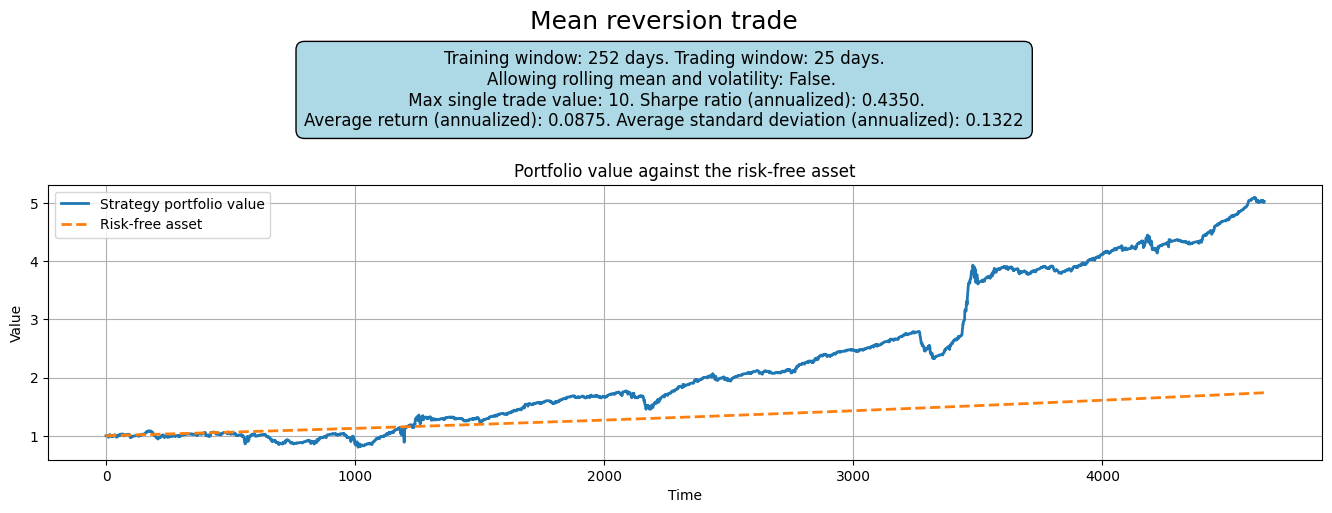

Overall log return of the strategy: 1.615015679801237


In [ ]:
#%% Plot

nrows =  1  
height_ratios =  [3]

fig = plt.figure(figsize=(14, 5))
gs = fig.add_gridspec(nrows, 1, height_ratios=height_ratios, hspace=0.4)

# Title at the top
fig.suptitle("Mean reversion trade", fontsize=18)

# Blue box as a figure-level annotation, not an axes
sharpe_text = (
    #f"Using the first {trade_horizon} days. "
    f"Training window: {training_period} days. Trading window: {trade_period} days.\n"
    f"Allowing rolling mean and volatility: {allow_rolling_estimations}. \n "
    f"Max single trade value: {max_leverage}. "
    f"Sharpe ratio (annualized): {sharpe_ratio:.4f}.\n"
    f"Average return (annualized): {np.mean(strategy_returns) * 252:.4f}. "
    f"Average standard deviation (annualized): {np.std(strategy_returns) * np.sqrt(252):.4f}"
)
fig.text(
    0.5, 0.9,
    sharpe_text,
    fontsize=12,
    ha='center',
    va='top',
    multialignment='center',
    bbox=dict(facecolor='lightblue', edgecolor='black', boxstyle='round,pad=0.5')
)

# Plot starts lower to make room for the text box
ax1 = fig.add_subplot(gs[0])
ax1.set_position([0.06, 0.08, 0.91, 0.55])
ax1.plot(portfolio_value, label='Strategy portfolio value', linewidth=2)
ax1.plot(risk_free_asset, label='Risk-free asset', linestyle='--', linewidth=2)
ax1.set_title("Portfolio value against the risk-free asset")
ax1.set_xlabel("Time")
ax1.set_ylabel("Value")
ax1.legend()
ax1.grid(True)


plt.savefig("../MeanReversionPlots/MR4.png")
plt.show()
